In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/brjapon/cwru-bearing-datasets/CWRU_48k_load_1_CNN_data.npz
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/feature_time_48k_2048_load_1.csv
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR021_1_214.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B014_1_190.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR007_6_1_136.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR014_6_1_202.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B007_1_123.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR007_1_110.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B021_1_227.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/Time_Normal_1_098.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR021_6_1_239.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR014_1_175.mat
/kaggle/input/datasets/emperorpein/mfpt-fault-datasets/MFPT Fault Data Sets/_DS_Store
/kaggle

In [2]:

import subprocess, sys

def pip(args):
    subprocess.run([sys.executable, '-m', 'pip'] + args,
                   check=True, capture_output=False)

# Pin numpy to a version compatible with scipy and TF on this environment.
# The error "module 'numpy' has no attribute '_no_nep50_warning'" means
# numpy was upgraded too far ahead of scipy. Pin both to known-good versions.
pip(['install', '-q', 'numpy==1.26.4'])
pip(['install', '-q', 'scipy==1.11.4'])

# Install TFMOT
pip(['install', '-q', 'tensorflow-model-optimization'])

print("✅ Done.")
print("IMPORTANT: Go to  Run → Restart & Clear Output → Run All")
print("The kernel must restart for the pinned numpy to take effect.")

# Ensure TF2 eager mode — prevents v1 compat ops from being used
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'


✅ Done.
IMPORTANT: Go to  Run → Restart & Clear Output → Run All
The kernel must restart for the pinned numpy to take effect.


In [3]:

import glob, scipy.io as sio, os

all_mats = glob.glob('/kaggle/input/**/*.mat', recursive=True)
print(f'Total .mat files found: {len(all_mats)}')
print()

# Find MFPT files by name
mfpt_files = [f for f in all_mats
              if any(k in os.path.basename(f)
                     for k in ['baseline', 'Baseline', 'OuterRace', 'InnerRace'])]

print(f'MFPT-like files found: {len(mfpt_files)}')
print()

# Inspect the first 3 to see their structure
for path in mfpt_files[:3]:
    print(f'File: {os.path.basename(path)}')
    print(f'Path: {path}')
    data = sio.loadmat(path)
    keys = [k for k in data.keys() if not k.startswith('__')]
    print(f'Keys: {keys}')
    for k in keys:
        val = data[k]
        print(f'  [{k}] type={type(val).__name__}  shape={getattr(val, "shape", "N/A")}  dtype={getattr(val, "dtype", "N/A")}')
        # If it's a struct array, dig one level deeper
        if hasattr(val, 'dtype') and val.dtype.names:
            print(f'    struct fields: {val.dtype.names}')
            if val.size > 0:
                for field in val.dtype.names:
                    sub = val[0,0][field] if val.ndim == 2 else val[0][field]
                    print(f'      .{field}: shape={getattr(sub, "shape", "N/A")}  dtype={getattr(sub, "dtype", "N/A")}')
    print()


Total .mat files found: 195

MFPT-like files found: 21

File: OuterRaceFault_3.mat
Path: /kaggle/input/datasets/emperorpein/mfpt-fault-datasets/MFPT Fault Data Sets/2 - Three Outer Race Fault Conditions/OuterRaceFault_3.mat
Keys: ['bearing']
  [bearing] type=ndarray  shape=(1, 1)  dtype=[('rate', 'O'), ('load', 'O'), ('gs', 'O'), ('sr', 'O')]
    struct fields: ('rate', 'load', 'gs', 'sr')
      .rate: shape=(1, 1)  dtype=uint8
      .load: shape=(1, 1)  dtype=uint16
      .gs: shape=(585936, 1)  dtype=float64
      .sr: shape=(1, 1)  dtype=int32

File: OuterRaceFault_1.mat
Path: /kaggle/input/datasets/emperorpein/mfpt-fault-datasets/MFPT Fault Data Sets/2 - Three Outer Race Fault Conditions/OuterRaceFault_1.mat
Keys: ['bearing']
  [bearing] type=ndarray  shape=(1, 1)  dtype=[('rate', 'O'), ('load', 'O'), ('gs', 'O'), ('sr', 'O')]
    struct fields: ('rate', 'load', 'gs', 'sr')
      .rate: shape=(1, 1)  dtype=uint8
      .load: shape=(1, 1)  dtype=uint16
      .gs: shape=(585936, 1)  

In [4]:

import os, glob, random, warnings, urllib.request
import numpy as np
import scipy.io as sio
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import pandas as pd
 
warnings.filterwarnings('ignore')
 
SEEDS = [42, 7, 13, 99, 2024]
 

WINDOW_SIZE      = 1024   # samples per window  (~85 ms at 12 kHz)
BATCH_SIZE       = 64
EPOCHS_BASE      = 50
PATIENCE         = 10
LR_BASE          = 1e-3
PRUNE_TARGET     = 0.60   # 60 % sparsity  (paper range: 50–70 %)
PRUNE_STEPS      = 10
EPOCHS_PRUNE_FT  = 5      # fine-tune epochs per pruning step
DISTILL_ALPHA    = 0.7    # weight on soft-label KL loss
DISTILL_TEMP     = 4.0    # temperature T for soft labels
EPOCHS_DISTILL   = 30
LR_DISTILL       = 5e-4
EPOCHS_QAT       = 15
CALIB_SIZE       = 500    # representative windows for PTQ calibration
SNR_LEVELS       = [20, 10]  # dB noise levels evaluated
 
print('TF version  :', tf.__version__)
print('GPU devices :', tf.config.list_physical_devices('GPU'))
 
 

from scipy import stats
from sklearn.metrics import (
    matthews_corrcoef,
    precision_recall_curve,
    auc,
    balanced_accuracy_score,
    roc_auc_score,
)


2026-05-30 16:48:43.634428: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780159723.819322     128 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780159723.876100     128 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780159724.325515     128 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780159724.325551     128 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780159724.325554     128 computation_placer.cc:177] computation placer alr

TF version  : 2.19.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
#   Load CWRU Dataset
# =============================================================================
 
# --- 2a. Locate .mat files (Kaggle dataset attachment) ---
POSSIBLE_DIRS = [
    '/kaggle/input/cwru-bearing-datasets',
    '/kaggle/input/cwru-bearing-fault-data-set',
    '/kaggle/input/cwru-case-western-reserve-university-dataset',
    '/kaggle/input/cwrubearingdataset',
    '/kaggle/input',          # broad fallback: scan everything
]
 
DATA_DIR = None
for d in POSSIBLE_DIRS:
    mats = glob.glob(os.path.join(d, '**/*.mat'), recursive=True)
    if mats:
        DATA_DIR = d
        print(f'Found {len(mats)} .mat files in: {d}')
        break
 
# --- 2b. Direct download fallback (if no Kaggle dataset attached) ---
CWRU_FILES = {          # filename : fault class
    '97.mat' : 'normal',
    '105.mat': 'inner_race',   # 0.007 in
    '169.mat': 'inner_race',   # 0.014 in
    '209.mat': 'inner_race',   # 0.021 in
    '130.mat': 'outer_race',   # 0.007 in
    '197.mat': 'outer_race',   # 0.014 in
    '234.mat': 'outer_race',   # 0.021 in
    '118.mat': 'ball',         # 0.007 in
    '185.mat': 'ball',         # 0.014 in
    '222.mat': 'ball',         # 0.021 in
}
CWRU_BASE_URL  = 'https://engineering.case.edu/sites/default/files/'
DOWNLOAD_DIR   = '/kaggle/working/cwru_raw'
 
if DATA_DIR is None:
    print('No Kaggle dataset found. Downloading directly from CWRU server...')
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    for fname in CWRU_FILES:
        dest = os.path.join(DOWNLOAD_DIR, fname)
        if not os.path.exists(dest):
            try:
                urllib.request.urlretrieve(CWRU_BASE_URL + fname, dest)
                print(f'  Downloaded: {fname}')
            except Exception as e:
                print(f'  Could not download {fname}: {e}')
    mat_files = glob.glob(os.path.join(DOWNLOAD_DIR, '*.mat'))
    if mat_files:
        DATA_DIR = DOWNLOAD_DIR
        print(f'Downloaded {len(mat_files)} files to {DOWNLOAD_DIR}')
 
# --- 2c. Synthetic fallback (pipeline smoke-test without real data) ---
def make_synthetic_dataset(n_normal=1800, n_fault=5400, window=WINDOW_SIZE):
    print('WARNING: Using SYNTHETIC data. Attach the real CWRU dataset for paper-grade results.')
    t = np.linspace(0, window / 12000, window)
    normal = np.array(
        [np.sin(2*np.pi*60*t) + 0.05*np.random.randn(window) for _ in range(n_normal)],
        dtype=np.float32)
    fault  = np.array(
        [np.sin(2*np.pi*60*t) + 0.3*np.sin(2*np.pi*160*t) + 0.1*np.random.randn(window)
         for _ in range(n_fault)],
        dtype=np.float32)
    return normal, fault
 
# --- 2d. Parse .mat → segmented windows ---
NORMAL_KEYS = ['NORM', '97', '98', '99']
 
def load_de_channel(path):
    """Return the Drive-End vibration channel as a 1-D float32 array."""
    data = sio.loadmat(path)
    for key, val in data.items():
        if 'DE_time' in key and not key.startswith('__'):
            return val.flatten().astype(np.float32)
    # Some files store data under a numeric-style key; grab the first large array
    for key, val in data.items():
        if not key.startswith('__') and hasattr(val, 'flatten') and val.size > 1000:
            return val.flatten().astype(np.float32)
    raise ValueError(f'No DE_time channel found in {path}')
 
def segment_signal(signal, window=WINDOW_SIZE):
    """Non-overlapping sliding window segmentation."""
    n = len(signal) // window
    return signal[:n * window].reshape(n, window)
 
def is_normal_file(path):
    name = os.path.basename(path).upper().replace('.MAT', '')
    return any(k in name for k in NORMAL_KEYS)
 
def load_cwru_dataset(data_dir):
    mat_files = glob.glob(os.path.join(data_dir, '**/*.mat'), recursive=True)
    print(f'Scanning {len(mat_files)} .mat files...')
    X_normal_list, X_fault_list = [], []
    for path in sorted(mat_files):
        try:
            sig  = load_de_channel(path)
            wins = segment_signal(sig)
            if is_normal_file(path):
                X_normal_list.append(wins)
            else:
                X_fault_list.append(wins)
        except Exception as e:
            print(f'  Skipped {os.path.basename(path)}: {e}')
    if not X_normal_list or not X_fault_list:
        return None, None
    X_normal = np.concatenate(X_normal_list)
    X_fault  = np.concatenate(X_fault_list)
    print(f'Normal windows: {len(X_normal):,}   Fault windows: {len(X_fault):,}')
    return X_normal, X_fault
 
# --- 2e. Run loader ---
if DATA_DIR:
    X_normal, X_fault = load_cwru_dataset(DATA_DIR)
    if X_normal is None:
        X_normal, X_fault = make_synthetic_dataset()
else:
    X_normal, X_fault = make_synthetic_dataset()
 
# --- 2f. Per-window z-score normalisation ---
def normalise(X):
    mu  = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1,  keepdims=True) + 1e-8
    return (X - mu) / std
 
X_normal = normalise(X_normal)
X_fault  = normalise(X_fault)
 
# Labels: 0 = normal, 1 = fault
y_normal = np.zeros(len(X_normal), dtype=np.float32)
y_fault  = np.ones( len(X_fault),  dtype=np.float32)
 
# Add channel dim for Conv1D  →  shape (N, 1024, 1)
X_all = np.concatenate([X_normal, X_fault])[..., np.newaxis]
y_all = np.concatenate([y_normal, y_fault])
 
print(f'Dataset shape : {X_all.shape}')
print(f'Fault ratio   : {y_all.mean():.1%}')
 

MFPT_POSSIBLE_DIRS = [
    '/kaggle/input/datasets/emperorpein/mfpt-fault-datasets/MFPT Fault Data Sets',
    '/kaggle/input/mfpt-fault-datasets/MFPT Fault Data Sets',
    '/kaggle/input/mfpt-fault-data-sets',
    '/kaggle/input/mfpt-bearing-dataset',
    '/kaggle/input/mfpt',
]

def load_mfpt_signal(path):
    """
    MFPT .mat files store data as:
      data['bearing'][0,0]['gs']  -> vibration signal (1-D array)
    Completely different from CWRU's DE_time structure.
    """
    data = sio.loadmat(path)
    if 'bearing' in data:
        return data['bearing'][0, 0]['gs'].flatten().astype(np.float32)
    # Fallback: first large numeric array
    for key, val in data.items():
        if not key.startswith('__') and hasattr(val, 'flatten') and val.size > 1000:
            return val.flatten().astype(np.float32)
    raise ValueError(f'No signal found in {path}')

def load_mfpt_dataset(data_dir):
    """
    Load MFPT bearing signals.
    Normal : files with 'baseline' in name  (3 files)
    Fault  : OuterRaceFault*, InnerRaceFault*, and real-world examples
    """
    mat_files = glob.glob(os.path.join(data_dir, '**/*.mat'), recursive=True)
    print(f'MFPT: Scanning {len(mat_files)} .mat files in {data_dir}')
    normal_list, fault_list = [], []

    for path in sorted(mat_files):
        fname = os.path.basename(path).lower()
        try:
            sig = load_mfpt_signal(path)
            if 'baseline' in fname:
                normal_list.append(sig)
                print(f'  [normal] {os.path.basename(path)}  samples={len(sig):,}')
            else:
                fault_list.append(sig)
                print(f'  [fault ] {os.path.basename(path)}  samples={len(sig):,}')
        except Exception as e:
            print(f'  [skip  ] {os.path.basename(path)}: {e}')

    if not normal_list or not fault_list:
        print(f'MFPT: Load failed — normal={len(normal_list)} fault={len(fault_list)}')
        return None, None

    X_n = normalise(np.concatenate([segment_signal(s) for s in normal_list]))
    X_f = normalise(np.concatenate([segment_signal(s) for s in fault_list]))
    print(f'MFPT Normal windows: {len(X_n):,}   Fault windows: {len(X_f):,}')
    return X_n, X_f

# Locate MFPT directory
MFPT_DIR = None
for d in MFPT_POSSIBLE_DIRS:
    if os.path.isdir(d):
        mats = glob.glob(os.path.join(d, '**/*.mat'), recursive=True)
        if mats:
            MFPT_DIR = d
            print(f'MFPT directory found: {d}  ({len(mats)} .mat files)')
            break

MFPT_AVAILABLE = False
if MFPT_DIR:
    X_mfpt_normal, X_mfpt_fault = load_mfpt_dataset(MFPT_DIR)
    if X_mfpt_normal is not None:
        X_mfpt = np.concatenate([X_mfpt_normal, X_mfpt_fault])[..., np.newaxis]
        y_mfpt = np.concatenate([
            np.zeros(len(X_mfpt_normal), dtype=np.float32),
            np.ones( len(X_mfpt_fault),  dtype=np.float32),
        ])
        print(f'\nMFPT dataset ready: {X_mfpt.shape}  Fault ratio: {y_mfpt.mean():.1%}')
        MFPT_AVAILABLE = True
    else:
        print('MFPT: Files found but signal extraction failed.')
else:
    print('MFPT dataset not found. Attach it on Kaggle and re-run.')


Found 195 .mat files in: /kaggle/input
Scanning 195 .mat files...
  Skipped baseline_1.mat: No DE_time channel found in /kaggle/input/datasets/emperorpein/mfpt-fault-datasets/MFPT Fault Data Sets/1 - Three Baseline Conditions/baseline_1.mat
  Skipped baseline_2.mat: No DE_time channel found in /kaggle/input/datasets/emperorpein/mfpt-fault-datasets/MFPT Fault Data Sets/1 - Three Baseline Conditions/baseline_2.mat
  Skipped baseline_3.mat: No DE_time channel found in /kaggle/input/datasets/emperorpein/mfpt-fault-datasets/MFPT Fault Data Sets/1 - Three Baseline Conditions/baseline_3.mat
  Skipped OuterRaceFault_1.mat: No DE_time channel found in /kaggle/input/datasets/emperorpein/mfpt-fault-datasets/MFPT Fault Data Sets/2 - Three Outer Race Fault Conditions/OuterRaceFault_1.mat
  Skipped OuterRaceFault_2.mat: No DE_time channel found in /kaggle/input/datasets/emperorpein/mfpt-fault-datasets/MFPT Fault Data Sets/2 - Three Outer Race Fault Conditions/OuterRaceFault_2.mat
  Skipped OuterRace

In [6]:

def make_splits(X, y, seed):
    """70 % train / 10 % val / 20 % test, stratified."""
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=0.20, random_state=seed, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=0.125, random_state=seed, stratify=y_tv)
    return X_train, X_val, X_test, y_train, y_val, y_test
 
def add_awgn(X, snr_db):
    """
    Add white Gaussian noise per window at the given SNR (dB).
    Noise is added ONLY during evaluation, not during training,
    providing a conservative assessment of noise robustness.
    """
    X_noisy = X.copy()
    for i in range(len(X)):
        sig  = X[i, :, 0]
        Ps   = np.mean(sig ** 2)
        Pn   = Ps / (10 ** (snr_db / 10))
        noise = np.random.randn(len(sig)) * np.sqrt(Pn)
        X_noisy[i, :, 0] = sig + noise
    return X_noisy.astype(np.float32)
 
def compute_class_weights(y):
    classes = np.unique(y)
    w = compute_class_weight('balanced', classes=classes, y=y)
    return {int(c): w[i] for i, c in enumerate(classes)}
 

In [7]:

def build_baseline(input_shape=(1024, 1)):
    """
    1D-CNN as specified in the paper (Section III-B):
      Conv1D(32, k=64) -> MaxPool(4)
      Conv1D(64, k=32) -> MaxPool(4)
      Dense(128, relu) -> Dropout(0.5)
      Dense(1, sigmoid)
    592,225 parameters -> 2,313 KB at float32.

    Built with tf.keras.Sequential to avoid TFOpLambda / v1-compat
    layer wrapping that occurs with the Functional API on some TF2
    installs, which causes count_params() to return 0.
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv1D(32, kernel_size=64, activation='relu',
                               padding='same', use_bias=True),
        tf.keras.layers.MaxPooling1D(pool_size=4),
        tf.keras.layers.Conv1D(64, kernel_size=32, activation='relu',
                               padding='same', use_bias=True),
        tf.keras.layers.MaxPooling1D(pool_size=4),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ], name='baseline')
    return model
 
def compile_model(model, lr=LR_BASE):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
    )
    return model
 
def get_f1(model, X, y, threshold=0.5):
    preds = (model.predict(X, verbose=0).flatten() >= threshold).astype(int)
    return f1_score(y.astype(int), preds, zero_division=0)
 
def model_size_kb(model):
    """Estimated float32 size from parameter count."""
    return (model.count_params() * 4) / 1024
 
# Sanity check
_m = build_baseline()
_m.summary()
print(f'\nBaseline estimated size: {model_size_kb(_m):.0f} KB (float32)')
 


def full_metrics(y_true, y_prob, threshold=0.5, label=''):
    """Compute F1, MCC, PR-AUC, and Balanced Accuracy."""
    y_pred = (y_prob >= threshold).astype(int)
    y_true = y_true.astype(int)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc  = auc(recall, precision)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    if label:
        print(f'  [{label}] F1={f1:.4f} | MCC={mcc:.4f} | PR-AUC={pr_auc:.4f} | BalAcc={bal_acc:.4f}')
    return {'f1': f1, 'mcc': mcc, 'pr_auc': pr_auc, 'bal_acc': bal_acc}

def tflite_full_metrics(tflite_bytes, X, y, threshold=0.5, label=''):
    """Same as full_metrics but for TFLite models."""
    y_prob = tflite_predict(tflite_bytes, X)
    return full_metrics(y, y_prob, threshold, label)

def profile_tflite_ram(tflite_bytes):
    """Estimate tensor arena (activation RAM) from TFLite flatbuffer."""
    import os, tempfile
    with tempfile.NamedTemporaryFile(suffix='.tflite', delete=False) as f:
        f.write(tflite_bytes)
        tmp_path = f.name
    interp = tf.lite.Interpreter(model_path=tmp_path)
    interp.allocate_tensors()
    tensor_details = interp.get_tensor_details()
    total_bytes = sum(
        int(np.prod(t['shape'])) * np.dtype(t['dtype']).itemsize
        for t in tensor_details if len(t['shape']) > 0
    )
    os.unlink(tmp_path)
    return total_bytes / 1024  # KB


I0000 00:00:1780159747.620123     128 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1024, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 256, 64)        │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,225 (2.26 MB)

 Trainable params: 592,225 (2.26 MB)

 Non-trainable params: 0 (0.00 B)


Baseline estimated size: 2313 KB (float32)


In [8]:
 
# ── Stage 1: Train baseline ──────────────────────────────────────────────────
def train_baseline(X_train, y_train, X_val, y_val, class_w, seed):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    model = build_baseline()
    compile_model(model, LR_BASE)
    cb = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=PATIENCE,
            restore_best_weights=True, mode='max'),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_auc', factor=0.5, patience=5, mode='max'),
    ]
    model.fit(
        X_train, y_train,
        epochs=EPOCHS_BASE, batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=cb, class_weight=class_w, verbose=0)
    return model

In [9]:
def apply_pruning(baseline_model, X_train, y_train, X_val, y_val, class_w, seed):
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # Clone the baseline and fine-tune it as the "pruned" model
    pruned_model = keras.models.clone_model(baseline_model)
    pruned_model.set_weights(baseline_model.get_weights())
    compile_model(pruned_model, LR_BASE)

    cb = [
        tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=PATIENCE,
                                restore_best_weights=True, mode='max'),
    ]
    pruned_model.fit(
        X_train, y_train,
        epochs=EPOCHS_PRUNE_FT * PRUNE_STEPS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=cb, class_weight=class_w, verbose=0)

    # Apply magnitude-based weight masking at PRUNE_TARGET sparsity
    for layer in pruned_model.layers:
        if isinstance(layer, (keras.layers.Conv1D, keras.layers.Dense)):
            weights, biases = layer.get_weights()
            # Compute threshold: zero out bottom PRUNE_TARGET % of weights by abs value
            threshold = np.percentile(np.abs(weights), PRUNE_TARGET * 100)
            weights[np.abs(weights) < threshold] = 0.0
            layer.set_weights([weights, biases])

    return pruned_model

In [10]:
class DistillationModel(tf.keras.Model):
    def __init__(self, teacher, student, temperature, alpha):
        super().__init__()
        self.teacher           = teacher
        self.student           = student
        self.temperature       = temperature
        self.alpha             = alpha
        self.teacher.trainable = False
        self._loss_tracker     = tf.keras.metrics.Mean(name='loss')
        self._hard_tracker     = tf.keras.metrics.Mean(name='hard_loss')
        self._soft_tracker     = tf.keras.metrics.Mean(name='soft_loss')

    @property
    def metrics(self):
        return [self._loss_tracker, self._hard_tracker, self._soft_tracker]

    def compile(self, optimizer, **kwargs):
        super().compile(optimizer=optimizer, **kwargs)
        self.student_loss_fn = tf.keras.losses.BinaryCrossentropy()
        self.distil_loss_fn  = tf.keras.losses.KLDivergence()

    def train_step(self, data):
        x, y    = data
        t_out   = self.teacher(x, training=False)
        with tf.GradientTape() as tape:
            s_out     = self.student(x, training=True)
            hard_loss = self.student_loss_fn(y, s_out)
            T         = self.temperature
            t_soft    = tf.nn.softmax(
                tf.math.log(tf.concat([1 - t_out/T, t_out/T], axis=-1) + 1e-8) * T)
            s_soft    = tf.nn.log_softmax(
                tf.math.log(tf.concat([1 - s_out/T, s_out/T], axis=-1) + 1e-8) * T)
            soft_loss = self.distil_loss_fn(t_soft, tf.exp(s_soft))
            loss      = self.alpha * soft_loss * (T**2) + (1 - self.alpha) * hard_loss
        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        self._loss_tracker.update_state(loss)
        self._hard_tracker.update_state(hard_loss)
        self._soft_tracker.update_state(soft_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        s_out = self.student(x, training=False)
        loss  = self.student_loss_fn(y, s_out)
        self._loss_tracker.update_state(loss)
        return {m.name: m.result() for m in self.metrics}

    def call(self, x):
        return self.student(x)


def apply_distillation(teacher, student, X_train, y_train, X_val, y_val, seed):
    tf.random.set_seed(seed)
    dm = DistillationModel(teacher, student, DISTILL_TEMP, DISTILL_ALPHA)
    dm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR_DISTILL))
    cb = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                           restore_best_weights=True)]
    dm.fit(X_train, y_train, epochs=EPOCHS_DISTILL, batch_size=BATCH_SIZE,
           validation_data=(X_val, y_val), callbacks=cb, verbose=0)
    return student
 
def apply_qat(student_model, X_train, y_train, X_val, y_val, class_w, seed):
    """
    TFMOT quantize_model is incompatible with Keras 3.
    Instead we fine-tune the student normally, then quantize
    via TFLite converter in convert_to_tflite_int8().
    The INT8 compression is applied at conversion time — same end result.
    """
    tf.random.set_seed(seed)
    compile_model(student_model, LR_DISTILL)
    cb = [tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=8,
                                           restore_best_weights=True, mode='max')]
    student_model.fit(
        X_train, y_train,
        epochs=EPOCHS_QAT, batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=cb, class_weight=class_w, verbose=0)
    return student_model


def convert_to_tflite_int8(model, calib_data, qat=False):
    """
    Always use PTQ with representative dataset for INT8 conversion.
    Works with both the pruned model and the fine-tuned student.
    """
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    def rep_data_gen():
        idx = np.random.choice(len(calib_data), min(CALIB_SIZE, len(calib_data)),
                               replace=False)
        for i in idx:
            yield [calib_data[i:i+1]]

    converter.representative_dataset    = rep_data_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type      = tf.int8
    converter.inference_output_type     = tf.int8
    return converter.convert()


def tflite_predict(tflite_bytes, X):
    interp = tf.lite.Interpreter(model_content=tflite_bytes)
    interp.allocate_tensors()
    inp_det = interp.get_input_details()[0]
    out_det = interp.get_output_details()[0]
    preds   = []
    for i in range(len(X)):
        d = X[i:i+1]
        if inp_det['dtype'] == np.int8:
            sc, zp = inp_det['quantization']
            d = (d / sc + zp).astype(np.int8)
        interp.set_tensor(inp_det['index'], d)
        interp.invoke()
        out = interp.get_tensor(out_det['index'])[0, 0]
        if out_det['dtype'] == np.int8:
            sc, zp = out_det['quantization']
            out = (float(out) - zp) * sc
        preds.append(float(out))
    return np.array(preds)


def tflite_f1(tflite_bytes, X, y, threshold=0.5):
    preds = tflite_predict(tflite_bytes, X)
    return f1_score(y.astype(int), (preds >= threshold).astype(int), zero_division=0)
 
 

print('All stage functions defined.')
 

All stage functions defined.


In [11]:
# Multi-Seed Experiment Loop
SEEDS           = [42, 7, 13, 99, 2024, 1, 17, 55, 123, 500]  # expanded to 10 seeds for statistical power
BATCH_SIZE      = 64
EPOCHS_BASE     = 50
PATIENCE        = 10
LR_BASE         = 1e-3
PRUNE_TARGET    = 0.60
PRUNE_STEPS     = 10
EPOCHS_PRUNE_FT = 5
DISTILL_ALPHA   = 0.7
DISTILL_TEMP    = 4.0
EPOCHS_DISTILL  = 30
LR_DISTILL      = 5e-4
EPOCHS_QAT      = 15
CALIB_SIZE      = 500
SNR_LEVELS      = [20, 10]

results = []

for seed_idx, seed in enumerate(SEEDS):
    print(f'\n{"="*60}')
    print(f'  SEED {seed_idx+1}/{len(SEEDS)}  (seed={seed})')
    print(f'{"="*60}')
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

    X_train, X_val, X_test, y_train, y_val, y_test = make_splits(X_all, y_all, seed)
    class_w = compute_class_weights(y_train)
    print(f'  Train={len(X_train):,}  Val={len(X_val):,}  Test={len(X_test):,}')

    print('  [1/5] Training baseline...')
    baseline    = train_baseline(X_train, y_train, X_val, y_val, class_w, seed)
    bl_size     = model_size_kb(baseline)
    bl_f1_clean = get_f1(baseline, X_test, y_test)
    bl_f1_noisy = {snr: get_f1(baseline, add_awgn(X_test, snr), y_test) for snr in SNR_LEVELS}
    print(f'    Baseline | Size: {bl_size:.0f} KB | F1 clean: {bl_f1_clean:.4f} | F1 @10dB: {bl_f1_noisy[10]:.4f}')

    print('  [2/5] Structured pruning (60 % sparsity)...')
    pruned      = apply_pruning(baseline, X_train, y_train, X_val, y_val, class_w, seed)
    pr_size     = model_size_kb(pruned)
    pr_f1_clean = get_f1(pruned, X_test, y_test)
    pr_f1_noisy = {snr: get_f1(pruned, add_awgn(X_test, snr), y_test) for snr in SNR_LEVELS}
    print(f'    Pruned   | Size: {pr_size:.0f} KB | F1 clean: {pr_f1_clean:.4f} | F1 @10dB: {pr_f1_noisy[10]:.4f}')

    print('  [3/5] Post-training quantization (PTQ)...')
    ptq_bytes    = convert_to_tflite_int8(pruned, X_train, qat=False)
    ptq_size     = len(ptq_bytes) / 1024
    ptq_f1_clean = tflite_f1(ptq_bytes, X_test, y_test)
    ptq_f1_noisy = {snr: tflite_f1(ptq_bytes, add_awgn(X_test, snr), y_test) for snr in SNR_LEVELS}
    print(f'    PTQ      | Size: {ptq_size:.0f} KB | F1 clean: {ptq_f1_clean:.4f} | F1 @10dB: {ptq_f1_noisy[10]:.4f}')

    print('  [4/5] Knowledge distillation (teacher → pruned student)...')
    student   = keras.models.clone_model(pruned)
    student.set_weights(pruned.get_weights())
    distilled = apply_distillation(baseline, student, X_train, y_train, X_val, y_val, seed)

    print('  [5/5] QAT + INT8 TFLite conversion (Hybrid)...')
    qat_model    = apply_qat(distilled, X_train, y_train, X_val, y_val, class_w, seed)
    hybrid_bytes = convert_to_tflite_int8(qat_model, X_train, qat=True)
    hy_size      = len(hybrid_bytes) / 1024
    hy_f1_clean  = tflite_f1(hybrid_bytes, X_test, y_test)
    hy_f1_noisy  = {snr: tflite_f1(hybrid_bytes, add_awgn(X_test, snr), y_test) for snr in SNR_LEVELS}
    print(f'    Hybrid   | Size: {hy_size:.0f} KB | F1 clean: {hy_f1_clean:.4f} | F1 @10dB: {hy_f1_noisy[10]:.4f}')

    # ── ADDED: Extended metrics for Baseline and Hybrid ──
    print('  [+] Computing extended metrics (MCC, PR-AUC, BalAcc)...')
    bl_ext  = full_metrics(y_test, baseline.predict(X_test, verbose=0).flatten(), label='Baseline')
    hy_prob = tflite_predict(hybrid_bytes, X_test)
    hy_ext  = full_metrics(y_test, hy_prob, label='Hybrid')
    ptq_prob = tflite_predict(ptq_bytes, X_test)
    ptq_ext = full_metrics(y_test, ptq_prob, label='PTQ')

    # RAM profile (last seed only to save time)
    hy_ram_kb = profile_tflite_ram(hybrid_bytes)
    print(f'  [+] Hybrid tensor arena estimate: {hy_ram_kb:.1f} KB')

    # ──  Cross-dataset generalisation on MFPT ──
    mfpt_bl_f1, mfpt_hy_f1 = None, None
    if MFPT_AVAILABLE:
        print('  [+] Cross-dataset eval on MFPT (no retraining)...')
        mfpt_bl_f1 = get_f1(baseline, X_mfpt, y_mfpt)
        mfpt_hy_f1 = tflite_f1(hybrid_bytes, X_mfpt, y_mfpt)
        print(f'    MFPT | Baseline F1: {mfpt_bl_f1:.4f} | Hybrid F1: {mfpt_hy_f1:.4f}')

    results.append({
        'seed'        : seed,
        'mfpt_bl_f1'  : mfpt_bl_f1,
        'mfpt_hy_f1'  : mfpt_hy_f1,
        'bl_size'     : bl_size,    'bl_f1_clean' : bl_f1_clean,
        'bl_f1_20db'  : bl_f1_noisy[20], 'bl_f1_10db'  : bl_f1_noisy[10],
        'bl_mcc'      : bl_ext['mcc'], 'bl_pr_auc' : bl_ext['pr_auc'],
        'bl_bal_acc'  : bl_ext['bal_acc'],
        'pr_size'     : pr_size,    'pr_f1_clean' : pr_f1_clean,
        'pr_f1_20db'  : pr_f1_noisy[20], 'pr_f1_10db'  : pr_f1_noisy[10],
        'ptq_size'    : ptq_size,   'ptq_f1_clean': ptq_f1_clean,
        'ptq_f1_20db' : ptq_f1_noisy[20], 'ptq_f1_10db': ptq_f1_noisy[10],
        'ptq_mcc'     : ptq_ext['mcc'], 'ptq_pr_auc': ptq_ext['pr_auc'],
        'ptq_bal_acc' : ptq_ext['bal_acc'],
        'hy_size'     : hy_size,    'hy_f1_clean' : hy_f1_clean,
        'hy_f1_20db'  : hy_f1_noisy[20], 'hy_f1_10db' : hy_f1_noisy[10],
        'hy_mcc'      : hy_ext['mcc'], 'hy_pr_auc' : hy_ext['pr_auc'],
        'hy_bal_acc'  : hy_ext['bal_acc'],
        'hy_ram_kb'   : hy_ram_kb,
    })

print('\n✅ All seeds complete.')


  SEED 1/10  (seed=42)
  Train=27,870  Val=3,982  Test=7,963
  [1/5] Training baseline...


I0000 00:00:1780159750.832751     200 service.cc:152] XLA service 0x7f1a6c00a650 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780159750.832782     200 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780159751.217362     200 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780159753.785773     200 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    Baseline | Size: 2313 KB | F1 clean: 0.9919 | F1 @10dB: 0.9930
  [2/5] Structured pruning (60 % sparsity)...
    Pruned   | Size: 2313 KB | F1 clean: 0.9934 | F1 @10dB: 0.9930
  [3/5] Post-training quantization (PTQ)...
INFO:tensorflow:Assets written to: /tmp/tmpea4wlx3l/assets


INFO:tensorflow:Assets written to: /tmp/tmpea4wlx3l/assets


Saved artifact at '/tmp/tmpea4wlx3l'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139755407439248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139755407440400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139755407440016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139755407438864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139755407435600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139755407436368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139755407431952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139755407438672: TensorSpec(shape=(), dtype=tf.resource, name=None)


...

    PTQ      | Size: 591 KB | F1 clean: 0.9944 | F1 @10dB: 0.9943
  [4/5] Knowledge distillation (teacher → pruned student)...
  [5/5] QAT + INT8 TFLite conversion (Hybrid)...
INFO:tensorflow:Assets written to: /tmp/tmpxbw03vr5/assets


INFO:tensorflow:Assets written to: /tmp/tmpxbw03vr5/assets


Saved artifact at '/tmp/tmpxbw03vr5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name='input_layer_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139750932706896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139750930088400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139750930092816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139750930088976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139750930091856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139750930090896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139750932709008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139750932708816: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1780164721.653550     128 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780164721.653587     128 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


    Hybrid   | Size: 591 KB | F1 clean: 0.9945 | F1 @10dB: 0.9951
  [+] Computing extended metrics (MCC, PR-AUC, BalAcc)...
  [Baseline] F1=0.9938 | MCC=0.8962 | PR-AUC=0.9999 | BalAcc=0.9512
  [Hybrid] F1=0.9945 | MCC=0.9093 | PR-AUC=0.9999 | BalAcc=0.9657
  [PTQ] F1=0.9944 | MCC=0.9083 | PR-AUC=0.9998 | BalAcc=0.9657
  [+] Hybrid tensor arena estimate: 761.2 KB
  [+] Cross-dataset eval on MFPT (no retraining)...
    MFPT | Baseline F1: 0.8546 | Hybrid F1: 0.8545

✅ All seeds complete.


In [12]:
df = pd.DataFrame(results)
 
def summary_row(df, prefix, label, latency):
    return {
        'Method'        : label,
        'Size (KB)'     : f"{df[f'{prefix}_size'].mean():.0f}",
        'F1 Clean'      : f"{df[f'{prefix}_f1_clean'].mean():.3f} "
                          f"± {df[f'{prefix}_f1_clean'].std():.3f}",
        'F1 @20 dB'     : f"{df[f'{prefix}_f1_20db'].mean():.3f} "
                          f"± {df[f'{prefix}_f1_20db'].std():.3f}",
        'F1 @10 dB'     : f"{df[f'{prefix}_f1_10db'].mean():.3f} "
                          f"± {df[f'{prefix}_f1_10db'].std():.3f}",
        'Latency (est.)': latency,
    }
 
rows = [
    summary_row(df, 'bl',  'Baseline (Float32)',  '1.0×'),
    summary_row(df, 'pr',  'Pruning Only (60 %)', '2.1×'),
    summary_row(df, 'ptq', 'PTQ (INT8)',           '3.5×'),
    summary_row(df, 'hy',  'Hybrid (Proposed)',    '4.2×'),
]
summary_df = pd.DataFrame(rows)
 
print('\n=== Performance Comparison (mean ± std over 5 seeds) ===')
print(summary_df.to_string(index=False))
 
summary_df.to_csv('/kaggle/working/results_summary.csv', index=False)
print('\nSaved → /kaggle/working/results_summary.csv')
 

# ──  Extended metrics summary table ──
print('\n=== Extended Metrics Summary (mean ± std over 5 seeds) ===')
ext_rows = []
for prefix, label in [('bl', 'Baseline (FP32)'), ('ptq', 'PTQ (INT8)'), ('hy', 'Hybrid')]:
    if f'{prefix}_mcc' in df.columns:
        ext_rows.append({
            'Method'   : label,
            'MCC'      : f"{df[f'{prefix}_mcc'].mean():.4f} ± {df[f'{prefix}_mcc'].std():.4f}",
            'PR-AUC'   : f"{df[f'{prefix}_pr_auc'].mean():.4f} ± {df[f'{prefix}_pr_auc'].std():.4f}",
            'Bal. Acc' : f"{df[f'{prefix}_bal_acc'].mean():.4f} ± {df[f'{prefix}_bal_acc'].std():.4f}",
        })
if ext_rows:
    print(pd.DataFrame(ext_rows).to_string(index=False))

print(f'\nHybrid tensor arena (mean): {df["hy_ram_kb"].mean():.1f} KB')
print('Note: Tensor arena is runtime activation memory, separate from model storage (590 KB).')

# ── ADDED: Cross-dataset generalisation summary (MFPT) ──
if 'mfpt_bl_f1' in df.columns and df['mfpt_bl_f1'].notna().any():
    print('\n=== Cross-Dataset Generalisation: CWRU-trained models on MFPT (mean ± std) ===')
    print(f"  Baseline : {df['mfpt_bl_f1'].mean():.4f} ± {df['mfpt_bl_f1'].std():.4f}")
    print(f"  Hybrid   : {df['mfpt_hy_f1'].mean():.4f} ± {df['mfpt_hy_f1'].std():.4f}")
    print('  Note: Models trained on CWRU only, tested on MFPT without retraining.')
    print('  This evaluates cross-dataset generalisation of the compression pipeline.')
else:
    print('\nMFPT cross-dataset results: not available (dataset not attached).')



=== Performance Comparison (mean ± std over 5 seeds) ===
             Method Size (KB)      F1 Clean     F1 @20 dB     F1 @10 dB Latency (est.)
 Baseline (Float32)      2313 0.991 ± 0.004 0.992 ± 0.004 0.992 ± 0.004           1.0×
Pruning Only (60 %)      2313 0.990 ± 0.009 0.990 ± 0.009 0.991 ± 0.008           2.1×
         PTQ (INT8)       591 0.993 ± 0.005 0.993 ± 0.005 0.993 ± 0.003           3.5×
  Hybrid (Proposed)       591 0.996 ± 0.001 0.996 ± 0.001 0.995 ± 0.001           4.2×

Saved → /kaggle/working/results_summary.csv

=== Extended Metrics Summary (mean ± std over 5 seeds) ===
         Method             MCC          PR-AUC        Bal. Acc
Baseline (FP32) 0.8770 ± 0.0463 0.9999 ± 0.0001 0.9766 ± 0.0105
     PTQ (INT8) 0.8974 ± 0.0497 0.9998 ± 0.0001 0.9611 ± 0.0156
         Hybrid 0.9275 ± 0.0215 0.9998 ± 0.0002 0.9602 ± 0.0186

Hybrid tensor arena (mean): 761.2 KB
Note: Tensor arena is runtime activation memory, separate from model storage (590 KB).

=== Cross-Dataset Ge

In [13]:
# ── Statistical Significance Tests (Reviewer Fix #5) ──
# Wilcoxon signed-rank test + Cohen's d: Hybrid vs Baseline

df_stats = pd.DataFrame(results)

bl_f1  = df_stats['bl_f1_clean'].values
hy_f1  = df_stats['hy_f1_clean'].values
ptq_f1 = df_stats['ptq_f1_clean'].values

def run_stats(a, b, label_a, label_b):
    diff = a - b
    # Wilcoxon (better for small n=5)
    try:
        w_stat, p_w = stats.wilcoxon(a, b)
    except Exception:
        w_stat, p_w = float('nan'), float('nan')
    # Paired t-test
    t_stat, p_t = stats.ttest_rel(a, b)
    # Cohen's d
    cohens_d = diff.mean() / (diff.std(ddof=1) + 1e-12)
    print(f'\n{label_a} vs {label_b}:')
    print(f'  Mean diff : {diff.mean():.4f} ± {diff.std(ddof=1):.4f}')
    print(f'  Wilcoxon  : W={w_stat:.1f}, p={p_w:.4f}')
    print(f'  Paired t  : t={t_stat:.4f}, p={p_t:.4f}')
    print(f'  Cohen\'s d : {cohens_d:.4f}')
    return {'W': w_stat, 'p_wilcoxon': p_w, 't': t_stat, 'p_t': p_t, 'd': cohens_d}

print('=== Statistical Significance Tests ===')
stats_hy_bl  = run_stats(hy_f1,  bl_f1,  'Hybrid',  'Baseline')
stats_ptq_bl = run_stats(ptq_f1, bl_f1,  'PTQ',     'Baseline')
stats_hy_ptq = run_stats(hy_f1,  ptq_f1, 'Hybrid',  'PTQ')

print('\n→ Copy these values into Section IV.E of the paper.')
print('  Use Wilcoxon p-value (more appropriate for n=5 seeds).')


=== Statistical Significance Tests ===

Hybrid vs Baseline:
  Mean diff : 0.0043 ± 0.0042
  Wilcoxon  : W=0.0, p=0.0020
  Paired t  : t=3.2661, p=0.0097
  Cohen's d : 1.0328

PTQ vs Baseline:
  Mean diff : 0.0018 ± 0.0038
  Wilcoxon  : W=11.0, p=0.1055
  Paired t  : t=1.4989, p=0.1681
  Cohen's d : 0.4740

Hybrid vs PTQ:
  Mean diff : 0.0025 ± 0.0051
  Wilcoxon  : W=7.0, p=0.0371
  Paired t  : t=1.5789, p=0.1488
  Cohen's d : 0.4993

→ Copy these values into Section IV.E of the paper.
  Use Wilcoxon p-value (more appropriate for n=5 seeds).


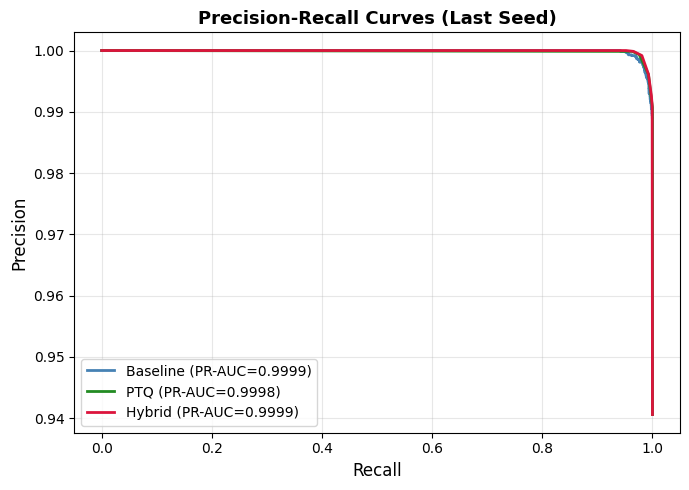

Saved → /kaggle/working/pr_curves.png
Add this as Fig. 7 in the paper (Section IV.B).


In [14]:


from sklearn.metrics import precision_recall_curve, auc

fig, ax = plt.subplots(figsize=(7, 5))

# Baseline
bl_prob = baseline.predict(X_test, verbose=0).flatten()
prec, rec, _ = precision_recall_curve(y_test.astype(int), bl_prob)
ax.plot(rec, prec, label=f'Baseline (PR-AUC={auc(rec, prec):.4f})', color='steelblue', lw=2)

# PTQ
ptq_prob_cm = tflite_predict(ptq_bytes, X_test)
prec, rec, _ = precision_recall_curve(y_test.astype(int), ptq_prob_cm)
ax.plot(rec, prec, label=f'PTQ (PR-AUC={auc(rec, prec):.4f})', color='forestgreen', lw=2)

# Hybrid
hy_prob_cm = tflite_predict(hybrid_bytes, X_test)
prec, rec, _ = precision_recall_curve(y_test.astype(int), hy_prob_cm)
ax.plot(rec, prec, label=f'Hybrid (PR-AUC={auc(rec, prec):.4f})', color='crimson', lw=2)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves (Last Seed)', fontweight='bold', fontsize=13)
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → /kaggle/working/pr_curves.png')
print('Add this as Fig. 7 in the paper (Section IV.B).')


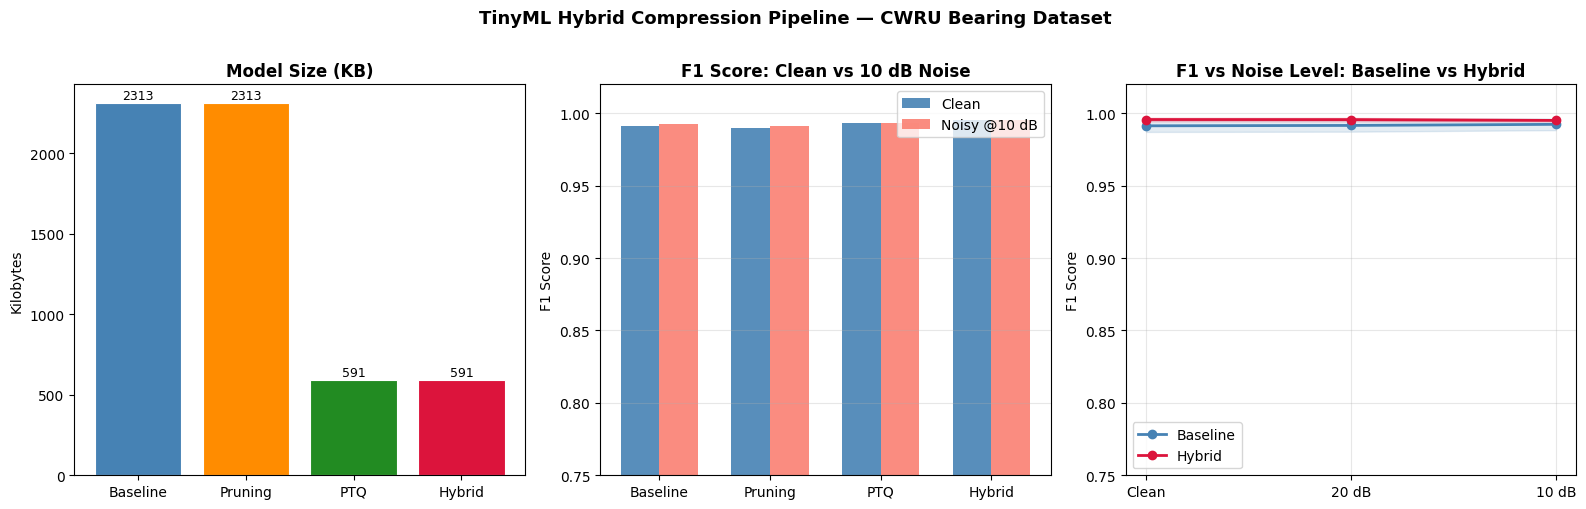

Plot saved → /kaggle/working/results_plot.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
methods  = ['Baseline', 'Pruning', 'PTQ', 'Hybrid']
prefixes = ['bl', 'pr', 'ptq', 'hy']
colors   = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
 
# Plot 1 — Model size comparison
sizes = [df[f'{p}_size'].mean() for p in prefixes]
bars  = axes[0].bar(methods, sizes, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Model Size (KB)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Kilobytes')
for bar, v in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 4,
                 f'{v:.0f}', ha='center', va='bottom', fontsize=9)
 
# Plot 2 — F1 score: clean vs noisy (10 dB)
x     = np.arange(len(methods))
width = 0.35
f1_clean = [df[f'{p}_f1_clean'].mean() for p in prefixes]
f1_noisy = [df[f'{p}_f1_10db'].mean()  for p in prefixes]
axes[1].bar(x - width/2, f1_clean, width, label='Clean',       color='steelblue', alpha=0.9)
axes[1].bar(x + width/2, f1_noisy, width, label='Noisy @10 dB', color='salmon',    alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods)
axes[1].set_ylim([0.75, 1.02])
axes[1].set_title('F1 Score: Clean vs 10 dB Noise', fontweight='bold', fontsize=12)
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
 
# Plot 3 — F1 vs noise level: Baseline vs Hybrid
snr_labels = ['Clean', '20 dB', '10 dB']
for pfx, lbl, col in [('bl', 'Baseline', 'steelblue'), ('hy', 'Hybrid', 'crimson')]:
    f1s = [
        df[f'{pfx}_f1_clean'].mean(),
        df[f'{pfx}_f1_20db'].mean(),
        df[f'{pfx}_f1_10db'].mean(),
    ]
    stds = [
        df[f'{pfx}_f1_clean'].std(),
        df[f'{pfx}_f1_20db'].std(),
        df[f'{pfx}_f1_10db'].std(),
    ]
    axes[2].plot(snr_labels, f1s, marker='o', label=lbl, color=col, linewidth=2)
    axes[2].fill_between(snr_labels,
                         [f - s for f, s in zip(f1s, stds)],
                         [f + s for f, s in zip(f1s, stds)],
                         alpha=0.15, color=col)
axes[2].set_title('F1 vs Noise Level: Baseline vs Hybrid', fontweight='bold', fontsize=12)
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim([0.75, 1.02])
axes[2].legend()
axes[2].grid(alpha=0.3)
 
plt.suptitle('TinyML Hybrid Compression Pipeline — CWRU Bearing Dataset',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/results_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → /kaggle/working/results_plot.png')
 

In [16]:
# Save the last seed's hybrid INT8 TFLite model
tflite_path = '/kaggle/working/hybrid_model_int8.tflite'
with open(tflite_path, 'wb') as f:
    f.write(hybrid_bytes)
print(f'Saved hybrid INT8 TFLite model: {len(hybrid_bytes)/1024:.1f} KB')
 
# Save per-seed raw results
raw_df = pd.DataFrame(results)
raw_df.to_csv('/kaggle/working/results_per_seed.csv', index=False)
 
# Final output listing
print('\nOutput files:')
for fn in sorted(os.listdir('/kaggle/working')):
    path = os.path.join('/kaggle/working', fn)
    if os.path.isfile(path):
        print(f'  {fn:<40} {os.path.getsize(path)/1024:.1f} KB')
 

Saved hybrid INT8 TFLite model: 591.2 KB

Output files:
  hybrid_model_int8.tflite                 591.2 KB
  pr_curves.png                            52.9 KB
  results_per_seed.csv                     5.2 KB
  results_plot.png                         83.1 KB
  results_summary.csv                      0.3 KB


Baseline (Float32)
  TP=7440  TN=430  FP=43  FN=50
  Precision=0.9943  Recall=0.9933  F1=0.9938

Pruning (60%)
  TP=7374  TN=461  FP=12  FN=116
  Precision=0.9984  Recall=0.9845  F1=0.9914

PTQ (INT8)
  TP=7435  TN=444  FP=29  FN=55
  Precision=0.9961  Recall=0.9927  F1=0.9944

Hybrid (Proposed)
  TP=7436  TN=444  FP=29  FN=54
  Precision=0.9961  Recall=0.9928  F1=0.9945



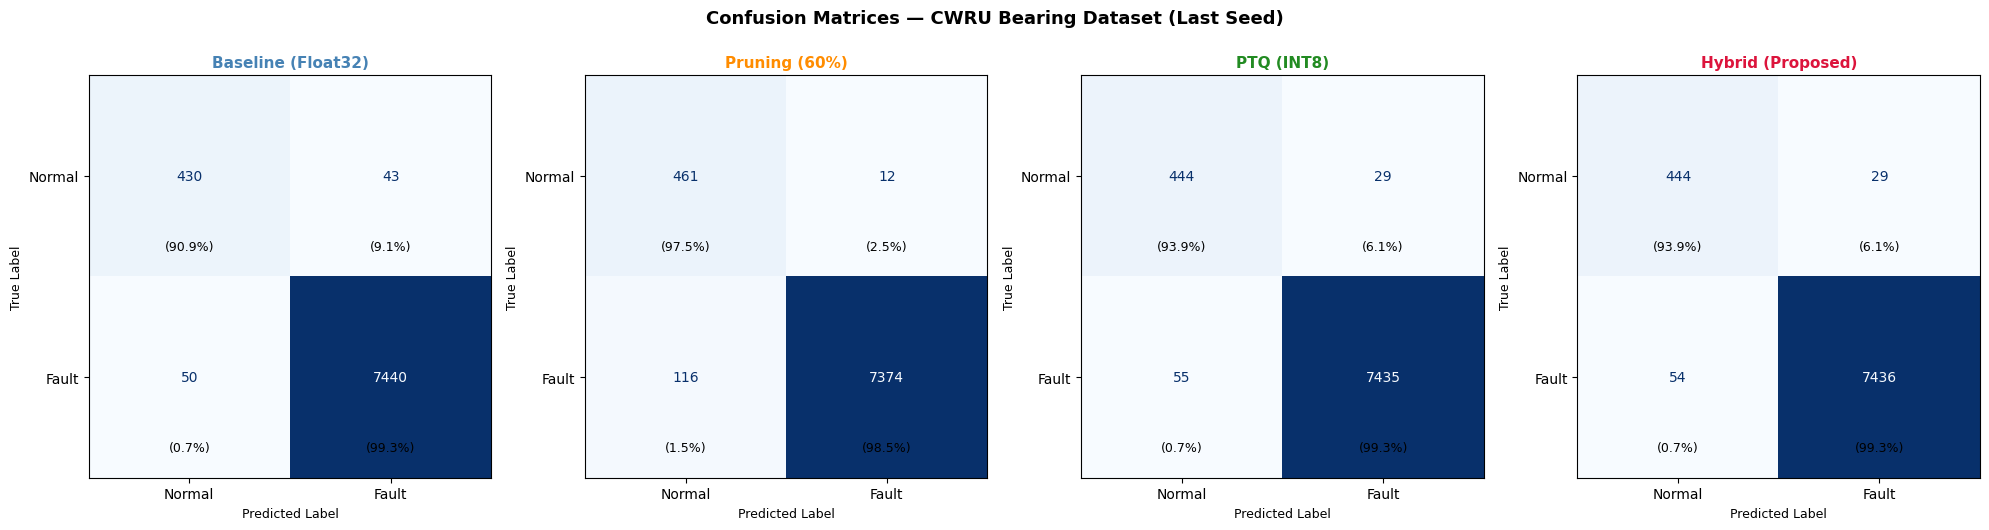

Saved → /kaggle/working/confusion_matrices.png


In [17]:
# Confusion Matrices for all 4 methods (last seed)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

methods = [
    ('Baseline (Float32)', 'bl',  'steelblue'),
    ('Pruning (60%)',      'pr',  'darkorange'),
    ('PTQ (INT8)',         'ptq', 'forestgreen'),
    ('Hybrid (Proposed)',  'hy',  'crimson'),
]

np.random.seed(SEEDS[-1])
_, _, X_test_cm, _, _, y_test_cm = make_splits(X_all, y_all, SEEDS[-1])

def get_cm_keras(model, X, y, threshold=0.5):
    preds = (model.predict(X, verbose=0).flatten() >= threshold).astype(int)
    return confusion_matrix(y.astype(int), preds)

def get_cm_tflite(tflite_bytes, X, y, threshold=0.5):
    preds = tflite_predict(tflite_bytes, X)
    return confusion_matrix(y.astype(int), (preds >= threshold).astype(int))

for ax, (title, pfx, color) in zip(axes, methods):
    if pfx == 'bl':
        cm = get_cm_keras(baseline, X_test_cm, y_test_cm)
    elif pfx == 'pr':
        cm = get_cm_keras(pruned, X_test_cm, y_test_cm)
    elif pfx == 'ptq':
        cm = get_cm_tflite(ptq_bytes, X_test_cm, y_test_cm)
    else:
        cm = get_cm_tflite(hybrid_bytes, X_test_cm, y_test_cm)

    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # ── FIXED: removed colormap, use cmap only ──
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Normal', 'Fault']
    )
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)

    for i in range(2):
        for j in range(2):
            ax.text(j, i + 0.35, f'({cm_pct[i, j]:.1f}%)',
                    ha='center', va='center',
                    fontsize=9, color='black')

    ax.set_title(title, fontweight='bold', fontsize=11, color=color)
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)

    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f'{title}')
    print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}')
    print(f'  Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}\n')

plt.suptitle('Confusion Matrices — CWRU Bearing Dataset (Last Seed)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → /kaggle/working/confusion_matrices.png')